Note: this analysis is carried out without cell types that contain NaNs.

In [1]:
import numpy as np
import pandas as pd
import scipy
from scipy import stats

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns

import pickle
import os

In [2]:
print(f"numpy=={np.__version__}")
print(f"pandas=={pd.__version__}")
print(f"scipy=={scipy.__version__}")
print(f"matplotlib=={matplotlib.__version__}")
print(f"seaborn=={sns.__version__}")

numpy==1.26.4
pandas==2.3.1
scipy==1.13.1
matplotlib==3.10.5
seaborn==0.13.2


Set paths, fix proportions, seeds and levels:

In [3]:
general_path = 'classif_matched_donorbased' # path to the results of the classification experiment

plots_path = "results_matched_donorbased" # path for output plots
if not os.path.exists(plots_path):
    os.makedirs(plots_path)


seeds = ['seed42', 'seed17', 'seed60', 'seed83']
proportions = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

# Helper functions

In [4]:
def gather_data(general_path, seed, ann_level):
    proportions = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

    # KNN
    metrics_knn = {'male': {}, 'female': {}}
        
    for key in metrics_knn.keys():
        metrics_knn[key] = {
            'accuracy': [],
            'median_f1': [],
            'mean_f1_per_class': [],
            'median_precision': [],
            'mean_prec_per_class': []
            }
    
    # read the file:
    male_lst = []
    female_lst = []
    for p in ['0', '01', '02', '03', '04', '05', '06', '07', '08', '09', '1']:
        male_file_path = f'{general_path}/{seed}/{ann_level}/{p}_male_metrics.pickle'
        female_file_path = f'{general_path}/{seed}/{ann_level}/{p}_female_metrics.pickle'
    
        with open(male_file_path, 'rb') as file:
            male_results = pickle.load(file)
        with open(female_file_path, 'rb') as file:
            female_results = pickle.load(file)
        male_lst.append(male_results)
        female_lst.append(female_results)

    # put them all together
    for i in range(len(male_lst)):
            male_result = male_lst[i]
            female_result = female_lst[i]
        
            metrics_knn['male']['accuracy'].append(male_result['accuracy'] if 'accuracy' in male_result.keys() else np.nan)
            metrics_knn['male']['median_f1'].append(male_result['median_f1']  if 'median_f1' in male_result.keys() else np.nan)
            metrics_knn['male']['median_precision'].append(male_result['median_precision']  if 'median_precision' in male_result.keys() else np.nan)
            metrics_knn['male']['mean_f1_per_class'].append(male_result['f1_scores']  if 'f1_scores' in male_result.keys() else [np.nan]*10)
            metrics_knn['male']['mean_prec_per_class'].append(male_result['precision_scores']  if 'precision_scores' in male_result.keys() else [np.nan]*10)
            
        
            metrics_knn['female']['accuracy'].append(female_result['accuracy'] if 'accuracy' in female_result.keys() else np.nan)
            metrics_knn['female']['median_f1'].append(female_result['median_f1']  if 'median_f1' in female_result.keys() else np.nan)
            metrics_knn['female']['median_precision'].append(female_result['median_precision']  if 'median_precision' in female_result.keys() else np.nan)
            metrics_knn['female']['mean_f1_per_class'].append(female_result['f1_scores']  if 'f1_scores' in female_result.keys() else [np.nan]*10)
            metrics_knn['female']['mean_prec_per_class'].append(female_result['precision_scores']  if 'precision_scores' in female_result.keys() else [np.nan]*10)

    return metrics_knn

In [5]:
def calculate_mean_variance(data):
    mean_data = np.mean(data, axis=0)
    std_data = np.std(data, axis=0)
    return mean_data, std_data

In [6]:
def gather_accuracies_ann_level(general_path, level, seeds):
    data_knn_male = []
    data_knn_female = []
    data_rf_male = []
    data_rf_female = []

    # loop over seeds and collect data
    for seed in seeds:
        metrics_knn = gather_data(general_path, seed, level)
        data_knn_male.append(metrics_knn['male']['accuracy'])
        data_knn_female.append(metrics_knn['female']['accuracy'])
    
    # calculate mean and variance
    mean_knn_male, var_knn_male = calculate_mean_variance(data_knn_male)
    mean_knn_female, var_knn_female = calculate_mean_variance(data_knn_female)

    return (mean_knn_male, var_knn_male, mean_knn_female, var_knn_female)

In [7]:
def plot_accuracy(proportions, general_path, level, seeds, title):
    plt.figure(figsize=(10, 5))

    (mean_knn_male, var_knn_male, mean_knn_female, var_knn_female) = gather_accuracies_ann_level(general_path, level, seeds)
    
    # plot mean accuracy line
    plt.plot(proportions, mean_knn_male, color='steelblue', label='Male test set', lw = 2)
    plt.plot(proportions, mean_knn_female, color='darkorange', label='Female test set', lw = 2)
    plt.legend(loc = 'lower left', fontsize = 12)
    
    # plot variance area
    plt.fill_between(proportions, mean_knn_male - var_knn_male, mean_knn_male + var_knn_male, color='steelblue', alpha=0.3)
    plt.fill_between(proportions, mean_knn_female - var_knn_female, mean_knn_female + var_knn_female, color='lightsalmon', alpha=0.5)
    
    plt.grid()

    title = title.split('_')[-1]
    plt.title(f'Annotation level {title}', fontsize = 15)
    plt.xlabel('% female samples', fontsize = 15)
    plt.ylabel('Accuracy', fontsize = 15)
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    plt.gca().tick_params(axis='y', which='major', labelsize=12)
    plt.gca().tick_params(axis='x', which='major', labelsize=12)
    
    plt.savefig(f'{plots_path}/knn_acc_{level}.png')
    plt.show()

# Results per annotation level

## ANN LEVEL 2

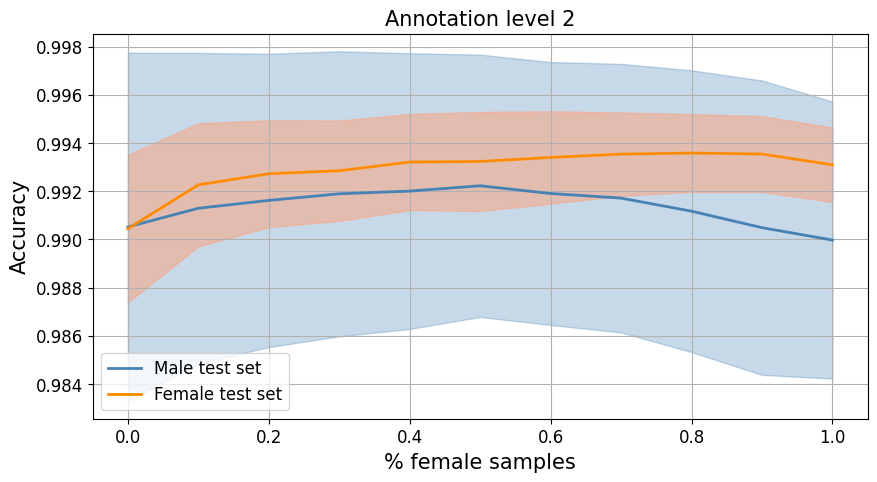

In [8]:
plot_accuracy(proportions, general_path, "ann_2", seeds, "Accuracy with increasing proportion of female samples at ann_2")

## ANN LEVEL 3

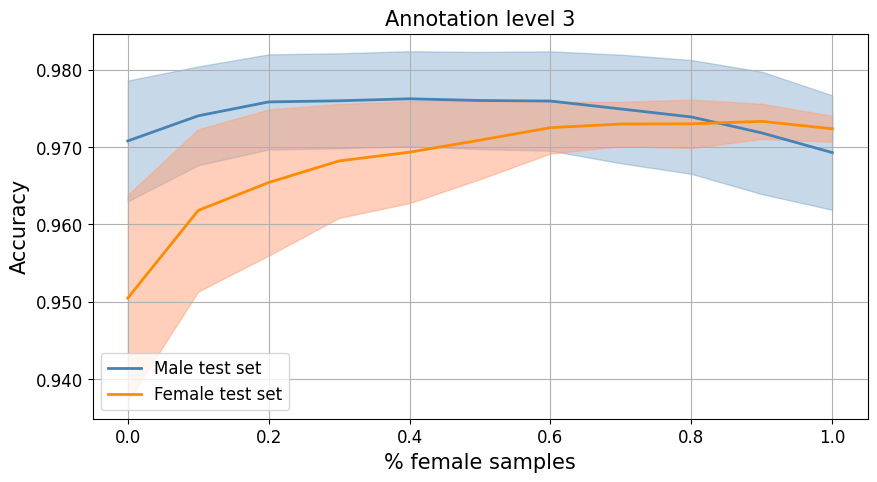

In [9]:
plot_accuracy(proportions, general_path, "ann_3", seeds, "Accuracy with increasing proportion of female samples at ann_3")

## ANN LEVEL 4

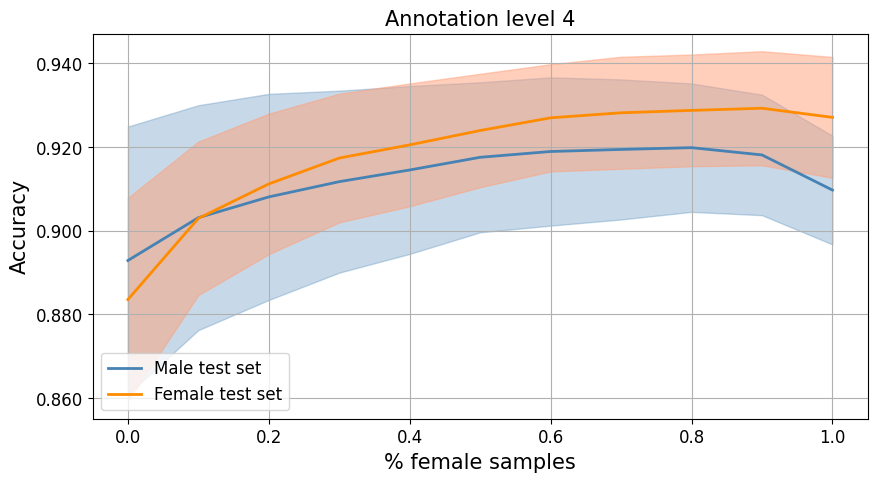

In [10]:
plot_accuracy(proportions, general_path, "ann_4", seeds, "Accuracy with increasing proportion of female samples at ann_4")

## FINEST ANN LEVEL

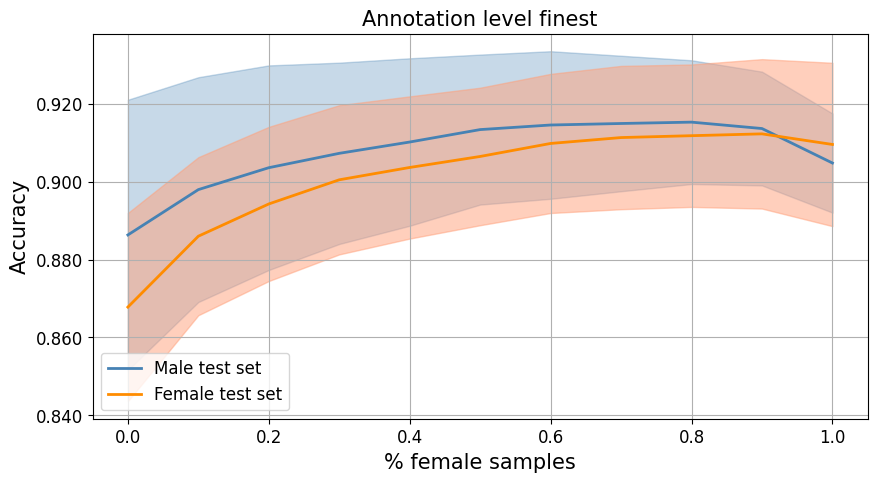

In [11]:
plot_accuracy(proportions, general_path, "ann_finest", seeds, "Accuracy with increasing proportion of female samples at ann_finest")

# Aggregated accuracy results

In [12]:
# function to plot accuracies on all annotation levels
def plot_accuracy_onax(ax, proportions, general_path, level, seeds, title, lims = None):
    (mean_knn_male, var_knn_male, mean_knn_female, var_knn_female) = gather_accuracies_ann_level(general_path, level, seeds)

    ax.plot(proportions, mean_knn_male, color='steelblue', label='Male test set', lw=2)
    ax.plot(proportions, mean_knn_female, color='darkorange', label='Female test set', lw=2)
    ax.legend(loc='lower left')

    ax.fill_between(proportions, mean_knn_male - var_knn_male, mean_knn_male + var_knn_male, color='steelblue', alpha=0.3)
    ax.fill_between(proportions, mean_knn_female - var_knn_female, mean_knn_female + var_knn_female, color='lightsalmon', alpha=0.5)
    
    ax.grid()
    ax.set_title(title, fontsize = 22)
    ax.set_ylabel('Accuracy', fontsize = 20)
    ax.set_ylim((0.85, 1))
    ax.legend(fontsize=17)

    if lims:
        ax.set_ylim(lims)

    ax.tick_params(axis='x', which='major', labelsize=16) 
    ax.tick_params(axis='y', which='major', labelsize=16) 

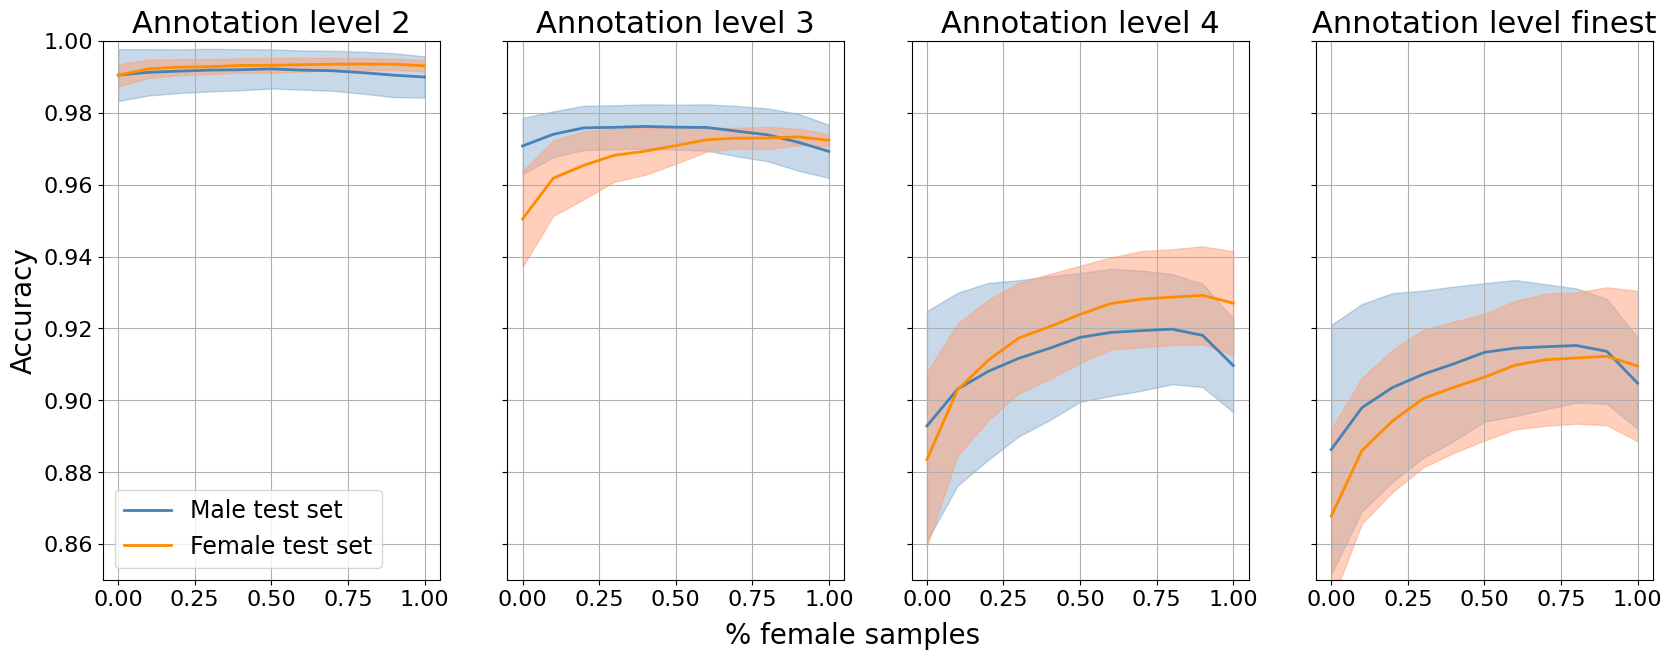

In [13]:
proportions = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
levels = ['ann_2', 'ann_3', 'ann_4', 'ann_finest']

fig, axs = plt.subplots(1, 4, sharey=True, figsize=(20,7))
for ax, level in zip(axs, levels):
    plot_accuracy_onax(ax, proportions, general_path, level, seeds, f"Annotation level {level.split('_')[-1]}", lims = (0.85, 1))
    if level != levels[0]:
        ax.legend().set_visible(False)  # ensure no legend for other plots
        ax.set_ylabel('') # and no y label
fig.supxlabel('% female samples', fontsize = 20)

plt.savefig(f'{plots_path}/knn_aggregated_acc.png') 
plt.show()